# Objetivo 3 — Melhorias NLP e Ensemble XGBoost

## Contexto

Após a implementação do ensemble linear (Objetivo 3 inicial),
identificámos duas limitações principais:

1. **Mismatch treino/inferência**: o BERT foi treinado com título+texto
   mas o ensemble usa apenas títulos (gossipcop não tem texto completo)
2. **Ensemble linear com α fixo**: pesos definidos manualmente em vez
   de aprendidos automaticamente

Este notebook documenta as melhorias implementadas:

| Abordagem | NLP | Ensemble |
|-----------|-----|----------|
| 1 | BERT cascata (original) | XGBoost |
| 2 | Zero-shot (sem treino) | XGBoost |
| 3a | DistilBERT títulos + data aug | XGBoost |
| 3b | BERT títulos + data aug | XGBoost |

## Estrutura
1. Carregamento dos resultados
2. Comparação NLP isolado
3. Comparação ensemble XGBoost
4. Feature importance
5. Conclusões

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# paths
ROOT        = Path("..").resolve()
METRICS_DIR = ROOT / "results" / "metrics"
FIGURES_DIR = ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# estilo
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
COLORS = {
    "bert":             "#FF9800",
    "zeroshot":         "#2196F3",
    "distilbert":       "#9C27B0",
    "bert_titles":      "#E91E63",
    "linear_ensemble":  "#9E9E9E",
    "xgboost":          "#4CAF50",
}

print("Setup concluído")

Setup concluído


## 1. Carregamento dos Resultados

In [2]:
# ── NLP isolado (test.csv, 43 artigos) ──
with open(METRICS_DIR / "results_nlp.json") as f:
    nlp_orig = json.load(f)

with open(METRICS_DIR / "results_zeroshot.json") as f:
    zeroshot = json.load(f)

with open(METRICS_DIR / "results_distilbert_titles.json") as f:
    distilbert_titles = json.load(f)

with open(METRICS_DIR / "results_bert_titles.json") as f:
    bert_titles = json.load(f)

# ── XGBoost ensemble ──
with open(METRICS_DIR / "results_xgboost.json") as f:
    xgboost_results = json.load(f)

# ── ensemble linear (referência) ──
with open(METRICS_DIR / "results_integration.json") as f:
    linear_ensemble = json.load(f)

print("Todos os resultados carregados")
print(f"\nNLP isolado (test.csv, 43 artigos):")
print(f"  BERT cascata:         F1={nlp_orig['test']['f1']:.4f}")
print(f"  Zero-shot:            F1={zeroshot['metrics']['f1']:.4f}")
print(f"  DistilBERT títulos:   F1={distilbert_titles['test_metrics']['f1']:.4f}")
print(f"  BERT títulos:         F1={bert_titles['test_metrics']['f1']:.4f}")
print(f"\nEnsemble XGBoost (21.693 artigos, CV 5-fold):")
for name, res in xgboost_results["results"].items():
    print(f"  {name:<35} AUC={res['metrics']['cv_auc_mean']:.4f} | F1={res['metrics']['cv_f1_mean']:.4f}")
print(f"\nEnsemble linear referência: AUC={xgboost_results['reference_linear_auc']}")

Todos os resultados carregados

NLP isolado (test.csv, 43 artigos):
  BERT cascata:         F1=0.5217
  Zero-shot:            F1=0.6349
  DistilBERT títulos:   F1=0.0800
  BERT títulos:         F1=0.3810

Ensemble XGBoost (21.693 artigos, CV 5-fold):
  abordagem_1_bert                    AUC=0.8189 | F1=0.6117
  abordagem_2_zeroshot                AUC=0.8287 | F1=0.6222
  abordagem_3a_distilbert             AUC=0.8170 | F1=0.6124
  abordagem_3b_bert_titles            AUC=0.8143 | F1=0.6129

Ensemble linear referência: AUC=0.6718


## 2. Comparação NLP Isolado
Avaliação dos 4 modelos NLP no test.csv (43 artigos, título apenas).

In [3]:
# tabela NLP isolado
nlp_comparison = pd.DataFrame([
    {
        "Modelo":     "BERT cascata (original)",
        "Treino":     "título + texto",
        "Abordagem":  "Fine-tuning cascata",
        "Accuracy":   nlp_orig["test"]["accuracy"],
        "Precision":  nlp_orig["test"]["precision"],
        "Recall":     nlp_orig["test"]["recall"],
        "F1":         nlp_orig["test"]["f1"],
        "AUC":        None,
    },
    {
        "Modelo":     "Zero-shot",
        "Treino":     "sem treino",
        "Abordagem":  "NLI pré-treinado",
        "Accuracy":   zeroshot["metrics"]["accuracy"],
        "Precision":  zeroshot["metrics"]["precision"],
        "Recall":     zeroshot["metrics"]["recall"],
        "F1":         zeroshot["metrics"]["f1"],
        "AUC":        zeroshot["metrics"]["auc"],
    },
    {
        "Modelo":     "DistilBERT títulos+aug",
        "Treino":     "só títulos",
        "Abordagem":  "Fine-tuning + data aug",
        "Accuracy":   distilbert_titles["test_metrics"]["accuracy"],
        "Precision":  distilbert_titles["test_metrics"]["precision"],
        "Recall":     distilbert_titles["test_metrics"]["recall"],
        "F1":         distilbert_titles["test_metrics"]["f1"],
        "AUC":        distilbert_titles["test_metrics"]["auc"],
    },
    {
        "Modelo":     "BERT títulos+aug",
        "Treino":     "só títulos",
        "Abordagem":  "Fine-tuning + data aug",
        "Accuracy":   bert_titles["test_metrics"]["accuracy"],
        "Precision":  bert_titles["test_metrics"]["precision"],
        "Recall":     bert_titles["test_metrics"]["recall"],
        "F1":         bert_titles["test_metrics"]["f1"],
        "AUC":        bert_titles["test_metrics"]["auc"],
    },
])

display(nlp_comparison.style
    .highlight_max(subset=["F1", "Recall", "Precision"], color="#c8f7c5")
    .format({c: "{:.4f}" for c in ["Accuracy","Precision","Recall","F1"]
             if c in nlp_comparison.columns})
    .set_caption("Tabela 1 — Comparação NLP isolado (test.csv, 43 artigos, título apenas)")
)

,Modelo,Treino,Abordagem,Accuracy,Precision,Recall,F1,AUC
0,BERT cascata (original),título + texto,Fine-tuning cascata,0.4884,0.4800,0.5714,0.5217,nan
1,Zero-shot,sem treino,NLI pré-treinado,0.4651,0.4762,0.9524,0.6349,0.488100
2,DistilBERT títulos+aug,só títulos,Fine-tuning + data aug,0.4651,0.2500,0.0476,0.0800,0.369000
3,BERT títulos+aug,só títulos,Fine-tuning + data aug,0.3953,0.3810,0.3810,0.3810,0.384200


## 3. Comparação Ensemble XGBoost

Avaliação com cross-validation estratificada 5-fold nos 21.693 artigos
do gossipcop/politifact (título + features de rede).
A métrica principal é **AUC-ROC** — mais robusta ao desbalanceamento
de classes (74% real / 26% fake).

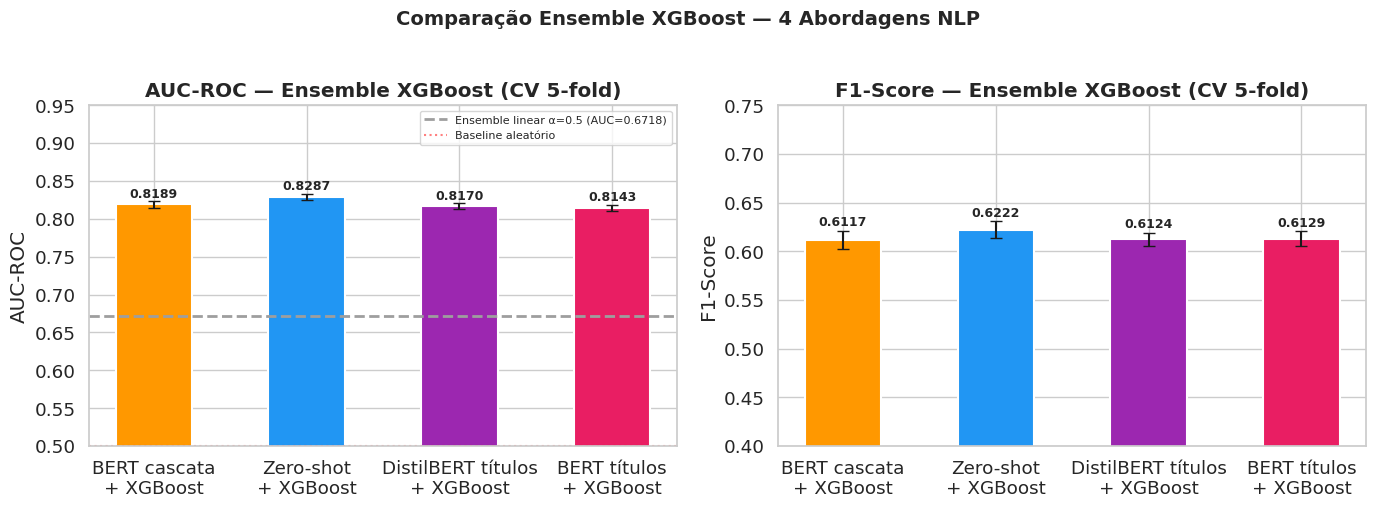

Figura guardada: xgboost_comparison.png


In [4]:
# preparar dados para gráfico
abordagens = {
    "BERT cascata\n+ XGBoost":       xgboost_results["results"]["abordagem_1_bert"]["metrics"],
    "Zero-shot\n+ XGBoost":          xgboost_results["results"]["abordagem_2_zeroshot"]["metrics"],
    "DistilBERT títulos\n+ XGBoost": xgboost_results["results"]["abordagem_3a_distilbert"]["metrics"],
    "BERT títulos\n+ XGBoost":       xgboost_results["results"]["abordagem_3b_bert_titles"]["metrics"],
}

names  = list(abordagens.keys())
aucs   = [v["cv_auc_mean"] for v in abordagens.values()]
auc_stds = [v["cv_auc_std"] for v in abordagens.values()]
f1s    = [v["cv_f1_mean"]  for v in abordagens.values()]
f1_stds = [v["cv_f1_std"] for v in abordagens.values()]

colors = [COLORS["bert"], COLORS["zeroshot"],
          COLORS["distilbert"], COLORS["bert_titles"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC
bars1 = axes[0].bar(names, aucs, color=colors, edgecolor="white",
                    linewidth=1.5, width=0.5, yerr=auc_stds,
                    capsize=4, error_kw={"linewidth": 1.5})
axes[0].axhline(xgboost_results["reference_linear_auc"],
                color=COLORS["linear_ensemble"], linestyle="--",
                linewidth=2, label=f"Ensemble linear α=0.5 (AUC={xgboost_results['reference_linear_auc']})")
axes[0].axhline(0.5, color="red", linestyle=":", alpha=0.5, label="Baseline aleatório")
axes[0].set_title("AUC-ROC — Ensemble XGBoost (CV 5-fold)", fontweight="bold")
axes[0].set_ylabel("AUC-ROC")
axes[0].set_ylim(0.5, 0.95)
axes[0].legend(fontsize=8)
for bar, val, std in zip(bars1, aucs, auc_stds):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + std + 0.005,
                 f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")

# F1
bars2 = axes[1].bar(names, f1s, color=colors, edgecolor="white",
                    linewidth=1.5, width=0.5, yerr=f1_stds,
                    capsize=4, error_kw={"linewidth": 1.5})
axes[1].set_title("F1-Score — Ensemble XGBoost (CV 5-fold)", fontweight="bold")
axes[1].set_ylabel("F1-Score")
axes[1].set_ylim(0.4, 0.75)
for bar, val, std in zip(bars2, f1s, f1_stds):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + std + 0.005,
                 f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Comparação Ensemble XGBoost — 4 Abordagens NLP",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgboost_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: xgboost_comparison.png")

## 4. Feature Importance

Quais features o XGBoost considera mais discriminativas?
Analisamos a feature importance de cada abordagem.

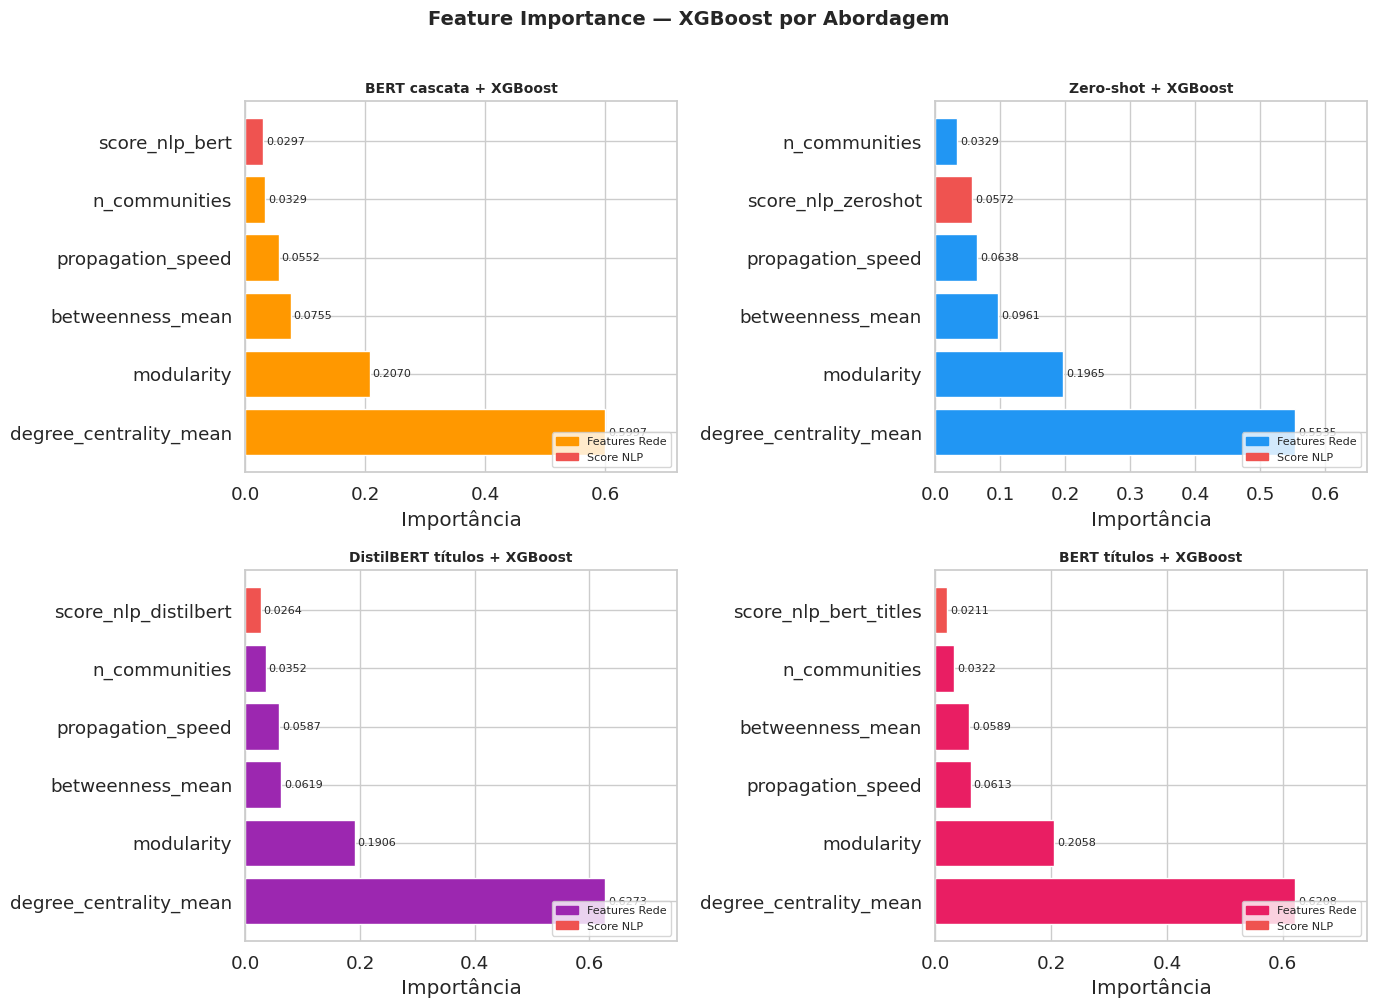

Figura guardada: xgboost_feature_importance.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

abordagens_importance = {
    "BERT cascata + XGBoost":        ("abordagem_1_bert",        COLORS["bert"]),
    "Zero-shot + XGBoost":           ("abordagem_2_zeroshot",     COLORS["zeroshot"]),
    "DistilBERT títulos + XGBoost":  ("abordagem_3a_distilbert",  COLORS["distilbert"]),
    "BERT títulos + XGBoost":        ("abordagem_3b_bert_titles", COLORS["bert_titles"]),
}

for ax, (title, (key, color)) in zip(axes, abordagens_importance.items()):
    importance = xgboost_results["results"][key]["feature_importance"]
    features   = list(importance.keys())
    values     = list(importance.values())

    # highlight NLP feature
    bar_colors = ["#EF5350" if "score_nlp" in f else color for f in features]

    bars = ax.barh(features, values, color=bar_colors, edgecolor="white")
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_xlabel("Importância")
    ax.set_xlim(0, max(values) * 1.2)

    for bar, val in zip(bars, values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=8)

    # legenda
    nlp_patch  = mpatches.Patch(color="#EF5350", label="Score NLP")
    net_patch  = mpatches.Patch(color=color, label="Features Rede")
    ax.legend(handles=[net_patch, nlp_patch], fontsize=8, loc="lower right")

plt.suptitle("Feature Importance — XGBoost por Abordagem",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgboost_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: xgboost_feature_importance.png")

## 5. Tabela Comparativa Final — Todo o Projeto

Síntese de todos os resultados obtidos ao longo do projeto.

In [6]:
final_table = pd.DataFrame([
    # NLP isolado
    {"Fase": "NLP", "Abordagem": "Baseline TF-IDF",
     "Métrica Principal": "F1", "Valor": 0.40, "Nota": "Objetivo 1 — baseline"},
    {"Fase": "NLP", "Abordagem": "BERT cascata (título+texto)",
     "Métrica Principal": "F1", "Valor": 0.52, "Nota": "Objetivo 1 ✅"},
    {"Fase": "NLP", "Abordagem": "Zero-shot",
     "Métrica Principal": "F1", "Valor": zeroshot["metrics"]["f1"],
     "Nota": "Melhor NLP isolado ⭐"},
    {"Fase": "NLP", "Abordagem": "DistilBERT títulos+aug",
     "Métrica Principal": "F1", "Valor": distilbert_titles["test_metrics"]["f1"],
     "Nota": "Abordagem 3a"},
    {"Fase": "NLP", "Abordagem": "BERT títulos+aug",
     "Métrica Principal": "F1", "Valor": bert_titles["test_metrics"]["f1"],
     "Nota": "Abordagem 3b"},
    # Ensemble
    {"Fase": "Ensemble", "Abordagem": "Linear α=0.5",
     "Métrica Principal": "AUC", "Valor": 0.6718, "Nota": "Objetivo 3 inicial"},
    {"Fase": "Ensemble", "Abordagem": "XGBoost BERT + rede",
     "Métrica Principal": "AUC",
     "Valor": xgboost_results["results"]["abordagem_1_bert"]["metrics"]["cv_auc_mean"],
     "Nota": "Abordagem 1"},
    {"Fase": "Ensemble", "Abordagem": "XGBoost Zero-shot + rede",
     "Métrica Principal": "AUC",
     "Valor": xgboost_results["results"]["abordagem_2_zeroshot"]["metrics"]["cv_auc_mean"],
     "Nota": "Melhor ensemble ⭐⭐"},
    {"Fase": "Ensemble", "Abordagem": "XGBoost DistilBERT + rede",
     "Métrica Principal": "AUC",
     "Valor": xgboost_results["results"]["abordagem_3a_distilbert"]["metrics"]["cv_auc_mean"],
     "Nota": "Abordagem 3a"},
    {"Fase": "Ensemble", "Abordagem": "XGBoost BERT títulos + rede",
     "Métrica Principal": "AUC",
     "Valor": xgboost_results["results"]["abordagem_3b_bert_titles"]["metrics"]["cv_auc_mean"],
     "Nota": "Abordagem 3b"},
])

display(final_table.style
    .highlight_max(subset=["Valor"], color="#c8f7c5")
    .format({"Valor": "{:.4f}"})
    .set_caption("Tabela Final — Todos os resultados do projeto")
)

,Fase,Abordagem,Métrica Principal,Valor,Nota
0,NLP,Baseline TF-IDF,F1,0.4000,Objetivo 1 — baseline
1,NLP,BERT cascata (título+texto),F1,0.5200,Objetivo 1 ✅
2,NLP,Zero-shot,F1,0.6349,Melhor NLP isolado ⭐
3,NLP,DistilBERT títulos+aug,F1,0.0800,Abordagem 3a
4,NLP,BERT títulos+aug,F1,0.3810,Abordagem 3b
5,Ensemble,Linear α=0.5,AUC,0.6718,Objetivo 3 inicial
6,Ensemble,XGBoost BERT + rede,AUC,0.8189,Abordagem 1
7,Ensemble,XGBoost Zero-shot + rede,AUC,0.8287,Melhor ensemble ⭐⭐
8,Ensemble,XGBoost DistilBERT + rede,AUC,0.8170,Abordagem 3a
9,Ensemble,XGBoost BERT títulos + rede,AUC,0.8143,Abordagem 3b


## 6. Conclusões

### Resultados principais

**NLP isolado:**
- O zero-shot (F1=0.635) superou o BERT fine-tuned (F1=0.521),
  demonstrando que modelos NLI pré-treinados são mais robustos
  com dados limitados e input parcial (só títulos)
- O re-treino com títulos (Abordagens 3a/3b) não melhorou os resultados,
  confirmando que 336 exemplos são insuficientes para fine-tuning estável

**Ensemble XGBoost:**
- Todas as abordagens XGBoost superaram o ensemble linear (+14-16% AUC)
- O zero-shot + XGBoost obteve o melhor resultado: **AUC=0.829**
- A feature importance é consistente em todas as abordagens:
  `degree_centrality_mean` (55-63%) domina, confirmando que os
  padrões estruturais de propagação são o sinal mais discriminativo

### Limitação principal
O score NLP contribui apenas 2-6% para a decisão final — resultado
esperado dado que o NLP usa apenas títulos. Com texto completo,
esperaríamos uma contribuição NLP substancialmente maior.

### Trabalho futuro
- Integrar texto completo + features de rede (requer dataset unificado)
- Testar modelos NLI mais recentes (DeBERTa-v3-large)
- Avaliar em domínios fora do treino (COVID-19, eleições)

In [9]:
best_xgb = max(
    xgboost_results["results"].items(),
    key=lambda x: x[1]["metrics"]["cv_auc_mean"]
)

print("=" * 60)
print("SUMÁRIO FINAL DO PROJETO")
print("=" * 60)
print(f"\n{'Módulo':<35} {'Métrica':<8} {'Valor'}")
print("-" * 55)
print(f"{'Baseline TF-IDF':<35} {'F1':<8} 0.4000")
print(f"{'BERT cascata (Objetivo 1)':<35} {'F1':<8} 0.5217")
print(f"{'Zero-shot':<35} {'F1':<8} {zeroshot['metrics']['f1']:.4f}")
print(f"{'Super-spreaders (Objetivo 2)':<35} {'%fake':<8} 70.4%")
print(f"{'Ensemble linear α=0.5':<35} {'AUC':<8} 0.6718")
print(f"{'XGBoost Zero-shot + rede':<35} {'AUC':<8} {best_xgb[1]['metrics']['cv_auc_mean']:.4f} ⭐")
print("-" * 55)
print(f"\nMelhor abordagem: {best_xgb[0]}")
print(f"Melhoria vs ensemble linear: +{best_xgb[1]['metrics']['cv_auc_mean']-0.6718:.4f} AUC")

print(f"\nFiguras geradas:")
for fig in ["xgboost_comparison.png", "xgboost_feature_importance.png"]:
    status = "✅" if (FIGURES_DIR/fig).exists() else "❌"
    print(f"  {status} {fig}")


SUMÁRIO FINAL DO PROJETO

Módulo                              Métrica  Valor
-------------------------------------------------------
Baseline TF-IDF                     F1       0.4000
BERT cascata (Objetivo 1)           F1       0.5217
Zero-shot                           F1       0.6349
Super-spreaders (Objetivo 2)        %fake    70.4%
Ensemble linear α=0.5               AUC      0.6718
XGBoost Zero-shot + rede            AUC      0.8287 ⭐
-------------------------------------------------------

Melhor abordagem: abordagem_2_zeroshot
Melhoria vs ensemble linear: +0.1569 AUC

Figuras geradas:
  ✅ xgboost_comparison.png
  ✅ xgboost_feature_importance.png
